# Intro to Cartopy

In [2]:
!pip install cartopy

   ---------------------------------------- 0.0/11.0 MB ? eta -:--:--
   ------------------------- -------------- 7.1/11.0 MB 48.7 MB/s eta 0:00:01
   ---------------------------------------- 11.0/11.0 MB 49.2 MB/s  0:00:00

   -------------------- ------------------- 1/2 [cartopy]
   -------------------- ------------------- 1/2 [cartopy]
   -------------------- ------------------- 1/2 [cartopy]
   -------------------- ------------------- 1/2 [cartopy]
   -------------------- ------------------- 1/2 [cartopy]
   -------------------- ------------------- 1/2 [cartopy]
   -------------------- ------------------- 1/2 [cartopy]
   -------------------- ------------------- 1/2 [cartopy]
   ---------------------------------------- 2/2 [cartopy]



In [9]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from cartopy import crs as ccrs, feature as cfeature

# suppress warnings issued by Cartopy when downloading data files
warnings.filterwarnings('ignore')

## Create a map with a specified projection

Creating a `GeoAxes` object that uses the `PlateCarree` projection (global lat-lon map projection also known as 'flat-square')

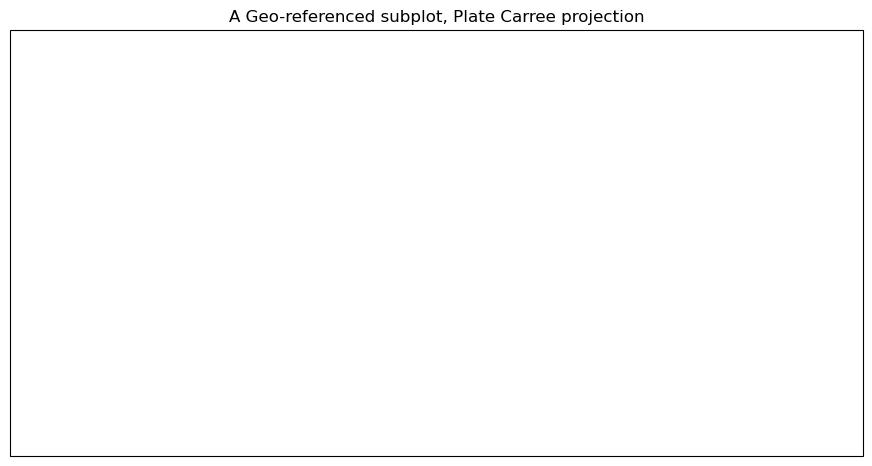

In [4]:
fig = plt.figure(figsize=(11,8.5))
ax = plt.subplot(1,1,1, projection=ccrs.PlateCarree(central_longitude=-75))
ax.set_title("A Geo-referenced subplot, Plate Carree projection");

appears empty, but can now add in cartographic features in the form of `shapefiles`.

An example is `GeoAxes` method called `coastlines`

In [5]:
ax.coastlines()

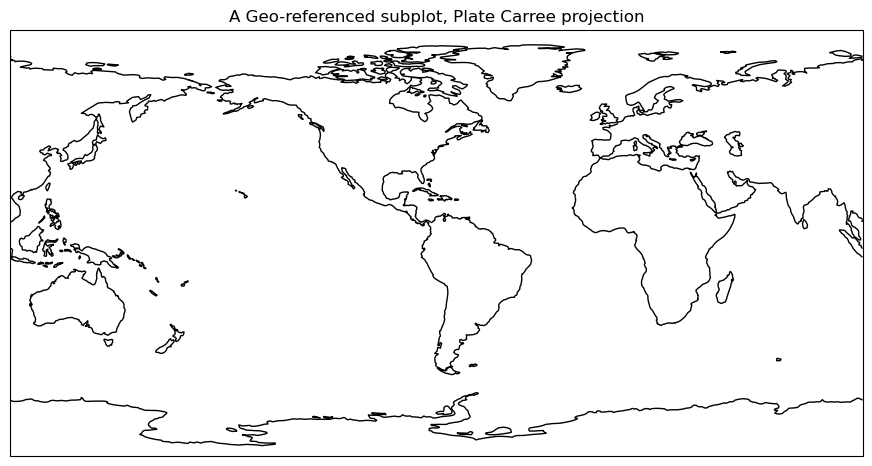

In [6]:
fig

## Add cartographic features to the map

Cartopy provides features via `feature` class imported as `cfeature`downloaded from https://www.naturalearthdata.com/ and live in your `'HOME'/.local/share/cartopy` directory. 

Add features via `add_feature` method - allows the definition of attributes using arguments similar to Matplotlibs `plot`.

In this example, adding borders and US state lines.

In [10]:
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black')
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')

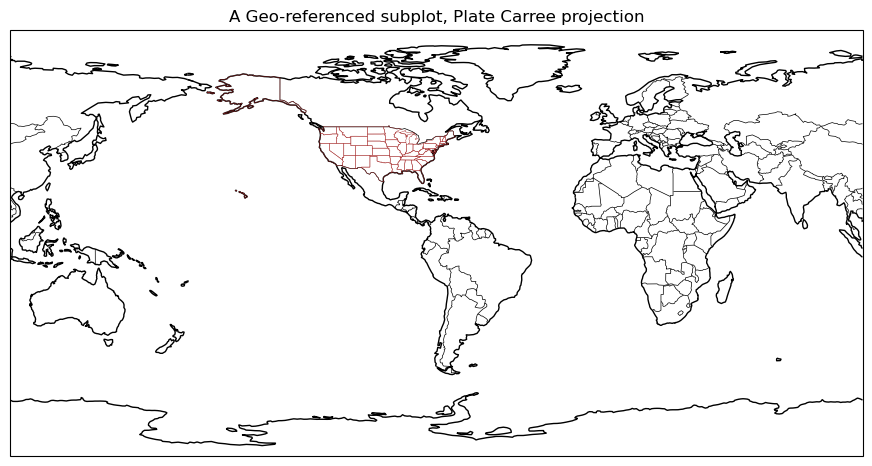

In [11]:
fig

## Create Regional Maps

### Cartopy's `set_extent` method
* Same projection created using `set_extent` to restrict the view to North America only. 
* choosing resolution of coastlines
* Plotting Lat/Lon
* **Only one resolution Band can be used at a time**
  

In [12]:
projPC = ccrs.PlateCarree()
lonW = -140
lonE = -40
latS = 15
latN = 65
cLat = (latN + latS) / 2
cLon = (lonW + lonE) / 2
res = '10m'

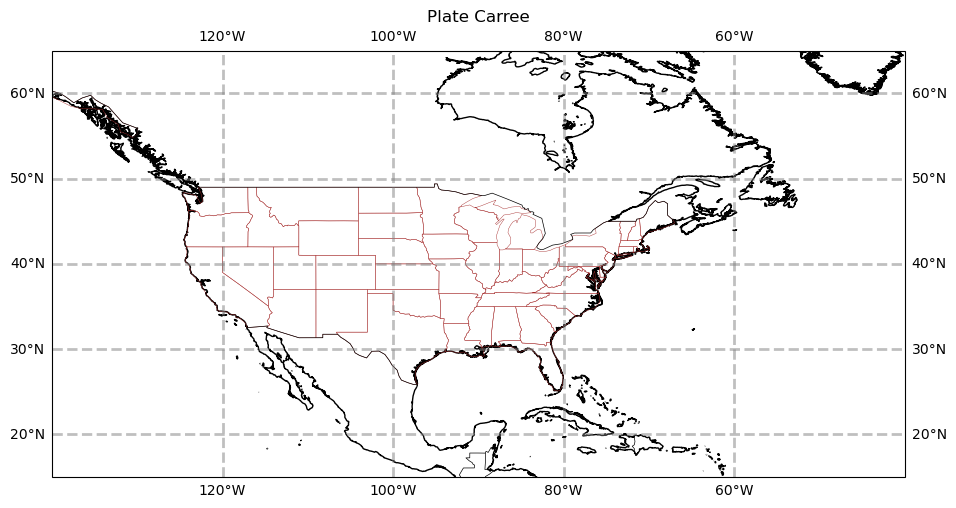

In [16]:
fig = plt.figure(figsize=(11, 8.5))
ax = plt.subplot(1, 1, 1, projection=projPC)
ax.set_title('Plate Carree')
gl = ax.gridlines(
    draw_labels=True, linewidth=2, color='gray', alpha=0.5, linestyle='--'
)
ax.set_extent([lonW, lonE, latS, latN], crs=projPC)
ax.coastlines(resolution=res, color='black')
ax.add_feature(cfeature.STATES, linewidth=0.3, edgecolor='brown')
ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='black');

"Please note, even though the calls to the subplot method use different projections, the calls to set_extent use PlateCarree. This ensures that the values we passed into set_extent will be transformed from degrees into the values appropriate for the projection we use for the map."

### Centered over a State

In [18]:
latN = 45.2
latS = 40.2
lonW = -80.0
lonE = -71.5
cLat = (latN + latS) / 2
cLon = (lonW + lonE) / 2
projLccNY = ccrs.LambertConformal(central_longitude=cLon, central_latitude=cLat)

Resolution of features depends on amount of geographical area specified by `set_extent`

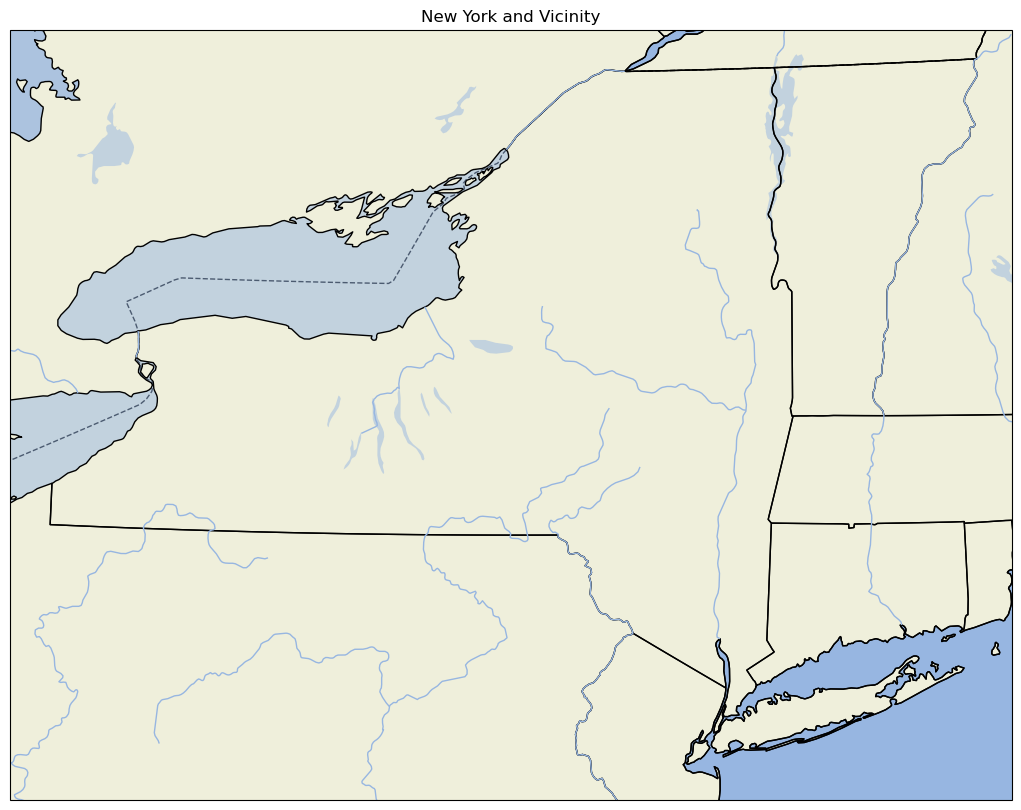

In [19]:
fig = plt.figure(figsize=(15, 10))
ax = plt.subplot(1, 1, 1, projection=projLccNY)
ax.set_extent([lonW, lonE, latS, latN], crs=projPC)
ax.set_facecolor(cfeature.COLORS['water'])
ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle='--')
ax.add_feature(cfeature.LAKES, alpha=0.5)
ax.add_feature(cfeature.STATES)
ax.add_feature(cfeature.RIVERS)
ax.set_title('New York and Vicinity');


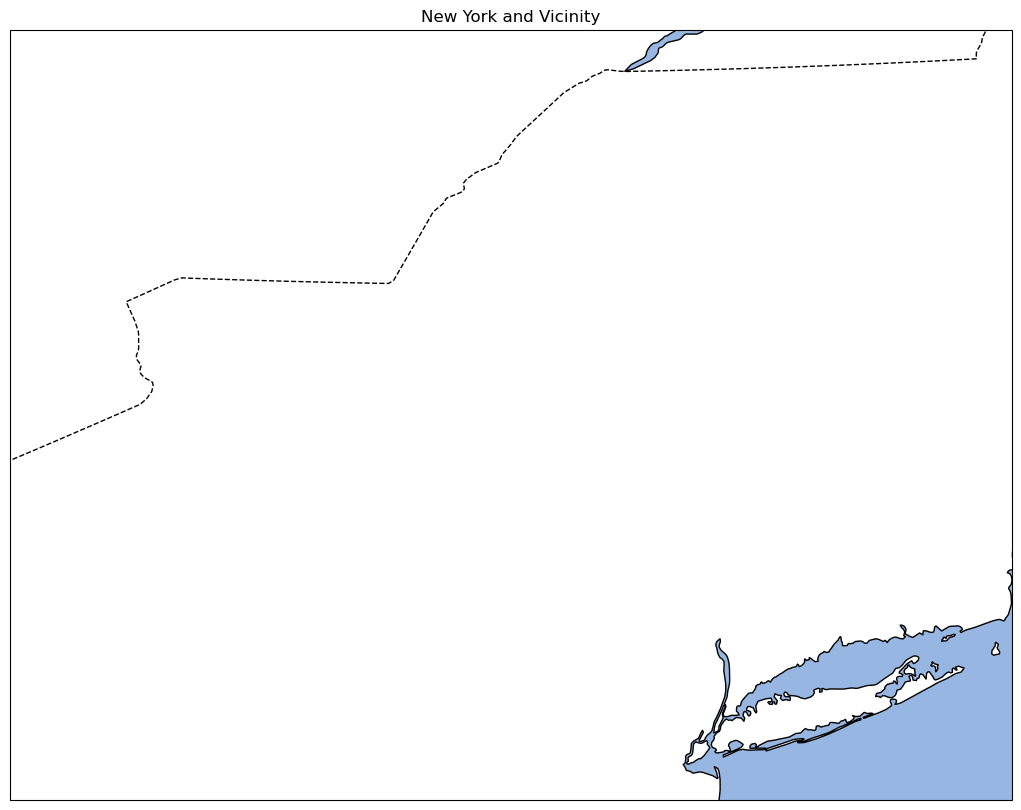

In [22]:
fig = plt.figure(figsize=(15, 10))
ax = plt.subplot(1, 1, 1, projection=projLccNY)
ax.set_extent([lonW, lonE, latS, latN], crs=projPC)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle='--')
ax.set_title('New York and Vicinity');

## `NaturalEarthFeature` Method
`NaturalEarthFeature` uses `add_feature` and is within `feaure` class in Cartopy.

Depending on features used is the amount of rendering time. **Cartopy has a `OCEAN` feature that takes a very long time but may be good for seagrass project**

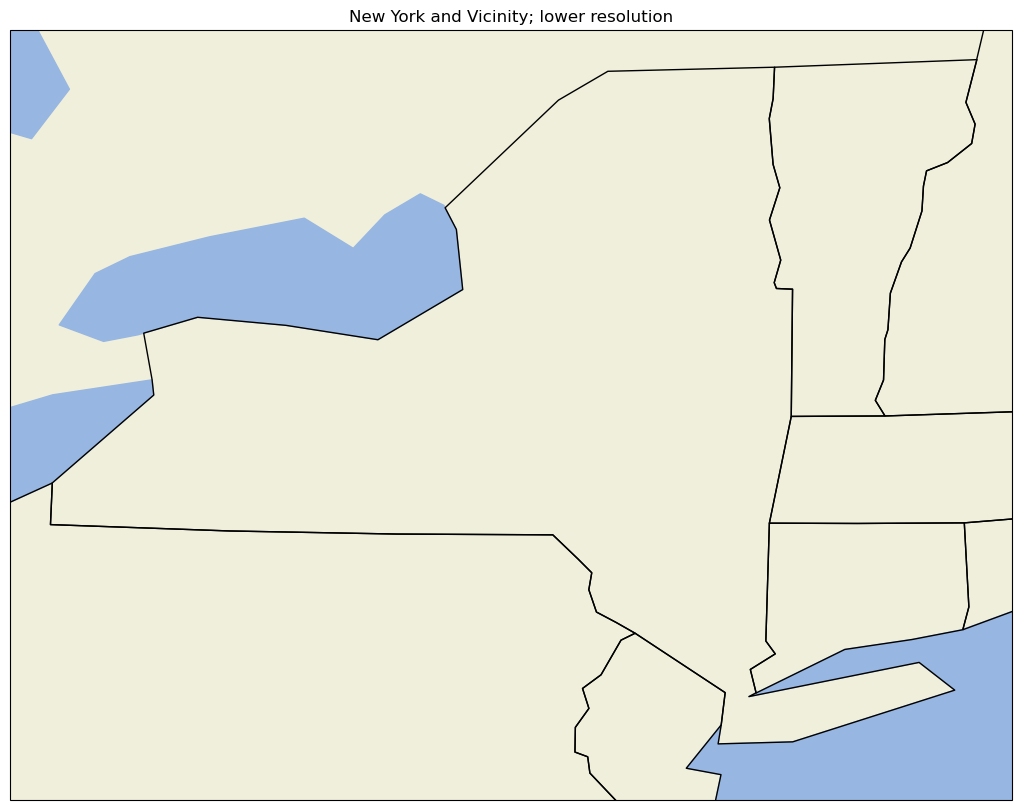

In [20]:
fig = plt.figure(figsize=(15, 10))
ax = plt.subplot(1, 1, 1, projection=projLccNY)
ax.set_extent((lonW, lonE, latS, latN), crs=projPC)

# The features with names such as cfeature.LAND, cfeature.OCEAN, are higher-resolution (10m)
# shapefiles from the Naturalearth repository.  Lower resolution shapefiles (50m, 110m) can be
# used by using the cfeature.NaturalEarthFeature method as illustrated below.

resolution = '110m'

land_mask = cfeature.NaturalEarthFeature(
    'physical',
    'land',
    scale=resolution,
    edgecolor='face',
    facecolor=cfeature.COLORS['land'],
)
sea_mask = cfeature.NaturalEarthFeature(
    'physical',
    'ocean',
    scale=resolution,
    edgecolor='face',
    facecolor=cfeature.COLORS['water'],
)
lake_mask = cfeature.NaturalEarthFeature(
    'physical',
    'lakes',
    scale=resolution,
    edgecolor='face',
    facecolor=cfeature.COLORS['water'],
)
state_borders = cfeature.NaturalEarthFeature(
    category='cultural',
    name='admin_1_states_provinces_lakes',
    scale=resolution,
    facecolor='none',
)

ax.add_feature(land_mask)
ax.add_feature(sea_mask)
ax.add_feature(lake_mask)
ax.add_feature(state_borders, linestyle='solid', edgecolor='black')
ax.set_title('New York and Vicinity; lower resolution');